In [1]:
import numpy as np
import pickle
from qiskit_nature.second_q.operators import SpinOp
from qiskit_nature.second_q.mappers import LogarithmicMapper
n_qubit = 1
dim     = 2**n_qubit
mapper = LogarithmicMapper()
t = 0.5
nld = 11
lds = np.linspace(0,1,num=nld)
Hld = []
i = 0
for ld in lds:
    h = SpinOp({
        "X_0": t,  
        "Z_0": -1.0 + 2.0* ld
    },
    spin=1/2
    )
    Hld.append(2*mapper.map(h.simplify())) # 2 is due to spin 1/2
    print(Hld[i])
    i +=1
h = SpinOp({
    "Z_0": 2.0
},
spin=1/2
)
Hp = 2*mapper.map(h.simplify()) # 2 is due to spin 1/2

# exact eigenvalues
ell  = np.zeros((nld,dim),dtype=float)
vll  = np.zeros((nld,dim,dim),dtype=complex)
for ild in range(nld):
    El, Vl = np.linalg.eigh(Hld[ild].to_matrix())
    indx = np.argsort(El.real)
    for i in range(dim):
        ell[ild,i]   = El[indx[i]].real
        vll[ild,:,i] = Vl[:,indx[i]]

X = np.zeros((2,2),dtype=complex)
Y = np.zeros((2,2),dtype=complex)
Z = np.zeros((2,2),dtype=complex)

X[0,1] = 1; X[1,0] = 1
Y[0,1] = -1j; Y[1,0] = 1j
Z[0,0] = 1; Z[1,1] = -1

# exact results
norm_exact   = np.ones((nld,dim),dtype=float)
E_exact      = np.zeros((nld,dim),dtype=float)
E_exact[0,:] = ell[0,:]
for k in range(dim):
    phi = vll[0,:,k]
    for ild in range(1,nld):
        Proj_matrix = np.outer(vll[ild,:,k],vll[ild,:,k].conj())
        phi = Proj_matrix@phi
        norm_exact[ild,k] = phi.conj()@phi
        E_exact[ild,k] = phi.conj()@Hld[ild].to_matrix()@phi/norm_exact[ild,k]
X_exact = np.zeros((nld,dim),dtype=float)
Y_exact = np.zeros((nld,dim),dtype=float)
Z_exact = np.zeros((nld,dim),dtype=float)
for ild in range(nld):
    for k in range(dim):
        X_exact[ild,k] = vll[ild,:,k].conj().transpose()@X@vll[ild,:,k]
        Y_exact[ild,k] = vll[ild,:,k].conj().transpose()@Y@vll[ild,:,k]
        Z_exact[ild,k] = vll[ild,:,k].conj().transpose()@Z@vll[ild,:,k]

SparsePauliOp(['X', 'Z'],
              coeffs=[ 0.5+0.j, -1. +0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[ 0.5+0.j, -0.8+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[ 0.5+0.j, -0.6+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[ 0.5+0.j, -0.4+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[ 0.5+0.j, -0.2+0.j])
SparsePauliOp(['X'],
              coeffs=[0.5+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[0.5+0.j, 0.2+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[0.5+0.j, 0.4+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[0.5+0.j, 0.6+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[0.5+0.j, 0.8+0.j])
SparsePauliOp(['X', 'Z'],
              coeffs=[0.5+0.j, 1. +0.j])


/tmp/ipykernel_66707/986796965.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  norm_exact[ild,k] = phi.conj()@phi
/tmp/ipykernel_66707/986796965.py:58: ComplexWarning: Casting complex values to real discards the imaginary part
  E_exact[ild,k] = phi.conj()@Hld[ild].to_matrix()@phi/norm_exact[ild,k]
/tmp/ipykernel_66707/986796965.py:64: ComplexWarning: Casting complex values to real discards the imaginary part
  X_exact[ild,k] = vll[ild,:,k].conj().transpose()@X@vll[ild,:,k]
/tmp/ipykernel_66707/986796965.py:65: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_exact[ild,k] = vll[ild,:,k].conj().transpose()@Y@vll[ild,:,k]
/tmp/ipykernel_66707/986796965.py:66: ComplexWarning: Casting complex values to real discards the imaginary part
  Z_exact[ild,k] = vll[ild,:,k].conj().transpose()@Z@vll[ild,:,k]


In [2]:
beta_list = []
norms_beta = []
std_norm_beta = []
E_beta = []
std_E_beta = []
with open('./supp-data/beta/beta.norm.E.save','r') as file_:
    i_beta = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        beta_list.append(float(ls[0]))
        norms_beta.append(float(ls[1]))
        std_norm_beta.append(float(ls[2]))
        E_beta.append(float(ls[3]))
        std_E_beta.append(float(ls[4]))
        beta = beta_list[i_beta]
        s = '{:.16e}'.format(beta)
        s += '  {:.16e}  {:.16e}'.format(norms_beta[i_beta],std_norm_beta[i_beta])
        s += '  {:.16e}  {:.16e}'.format(E_beta[i_beta],std_E_beta[i_beta])
        print(s)
        i_beta += 1

1.0000000000000001e-01  9.1023750000000059e-01  5.9494456301054247e-03  -1.0495230047777873e+00  6.7546093134375944e-03
2.5000000000000000e-01  5.9574999999999945e-01  2.1373023697798019e-02  -1.1880580794534237e+00  1.2292390232929742e-02
5.0000000000000000e-01  4.4700750000000028e-01  2.0609462255228608e-02  -1.2347633725464680e+00  1.9241065540161407e-02
1.0000000000000000e+00  6.6848250000000065e-01  1.2259133767911936e-02  -1.1713393237569372e+00  1.1005499365898393e-02
2.0000000000000000e+00  8.3088999999999946e-01  6.8650346698836415e-03  -1.1347921681050783e+00  7.5696333435353556e-03
3.0000000000000000e+00  8.6187374999999999e-01  6.2811476908316028e-03  -1.1228520128583837e+00  7.4529921795524010e-03
4.0000000000000000e+00  8.6737875000000020e-01  5.8665416039619155e-03  -1.1185051812585218e+00  7.4339146081831529e-03
5.0000000000000000e+00  8.6019874999999968e-01  5.9650538425640850e-03  -1.1233757472859143e+00  7.5655215329441944e-03
6.0000000000000000e+00  8.48823750000000

In [3]:
Nt_list = []
norms_Nt = []
std_norm_Nt = []
E_Nt = []
std_E_Nt = []
with open('./supp-data/n_trotter/Nt.norm.E.save','r') as file_:
    i_Nt = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        Nt_list.append(int(ls[0]))
        norms_Nt.append(float(ls[1]))
        std_norm_Nt.append(float(ls[2]))
        E_Nt.append(float(ls[3]))
        std_E_Nt.append(float(ls[4]))
        Nt = Nt_list[i_Nt]
        s = '{:}'.format(Nt)
        s += '  {:.16e}  {:.16e}'.format(norms_Nt[i_Nt],std_norm_Nt[i_Nt])
        s += '  {:.16e}  {:.16e}'.format(E_Nt[i_Nt],std_E_Nt[i_Nt])
        print(s)
        i_Nt += 1

1  -2.8826249999999987e-02  2.6376461348987745e-02  -3.4273593404068223e+00  4.1939513263955604e+01
2  -1.0221250000000022e-02  2.5933568113736982e-02  -7.3183898773790168e-01  1.9018350412961976e+01
3  9.8874999999999918e-03  2.4054972090874201e-02  3.4062995611945329e-01  2.2700144544707694e+01
4  4.7377499999999975e-02  2.4873373048182226e-02  -1.2055991388996032e+00  9.0389138267408512e+01
5  1.7242375000000010e-01  2.3824680768687087e-02  -1.1557546846413267e+00  5.5507959905800673e-02
6  3.0927000000000004e-01  2.2034914289684418e-02  -1.1517625630996180e+00  3.1377006192199366e-02
7  4.0332999999999997e-01  2.2179665121589399e-02  -1.1497126544603022e+00  2.3670798271398470e-02
8  4.9773625000000032e-01  1.9277018485094152e-02  -1.1427633463978764e+00  1.8147162064736499e-02
9  5.6866000000000017e-01  1.7277422061105517e-02  -1.1401310161632652e+00  1.5147974834468329e-02
10  6.2999500000000030e-01  1.5141539755323155e-02  -1.1367823040825216e+00  1.2970402055031024e-02
11  6.77

In [4]:
nld_list = []
norms_nld = []
std_norm_nld = []
E_nld = []
std_E_nld = []
with open('./supp-data/n_alpha/nld.norm.E.save','r') as file_:
    i_nld = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        nld_list.append(int(ls[0]))
        norms_nld.append(float(ls[1]))
        std_norm_nld.append(float(ls[2]))
        E_nld.append(float(ls[3]))
        std_E_nld.append(float(ls[4]))
        nld = nld_list[i_nld]
        s = '{:}'.format(nld)
        s += '  {:.16e}  {:.16e}'.format(norms_nld[i_nld],std_norm_nld[i_nld])
        s += '  {:.16e}  {:.16e}'.format(E_nld[i_nld],std_E_nld[i_nld])
        print(s)
        i_nld += 1

3  9.0274999999999921e-03  2.5196257242674245e-02  -8.8443428356413423e-01  3.0293925980848627e+01
5  5.4001625000000031e-01  1.5349019351713797e-02  -1.1222807288616214e+00  3.9814460267178931e-03
7  7.8780874999999995e-01  8.4645385043909636e-03  -1.1184915375196354e+00  1.8307725158565166e-03
9  8.1940500000000061e-01  7.6214237491730149e-03  -1.1190006978177374e+00  1.5317776398625959e-03
11  8.6174250000000030e-01  5.7413894863724514e-03  -1.1204537624245521e+00  1.4770221351502373e-03
16  8.9857125000000015e-01  4.6861766534338082e-03  -1.1181655725147153e+00  1.3999717325337154e-03
21  9.1491000000000111e-01  3.8316074392550216e-03  -1.1153402453229397e+00  1.3737927131989027e-03
26  9.3368249999999930e-01  3.1630612364660859e-03  -1.1176995835984040e+00  1.3670187998150360e-03
31  9.4764999999999977e-01  2.5255322389862553e-03  -1.1192412872629320e+00  1.3558957177146884e-03
36  9.5972375000000054e-01  1.8840095891410832e-03  -1.1168787616663547e+00  1.3398590155269733e-03
41  

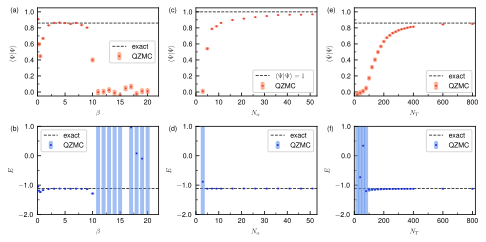

In [5]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size"  : 7
})

cm    = 1.0/2.54
width_col = 8.6*cm
width = width_col*2 
height = width_col
plt.figure(figsize=(width,height),dpi=600)

axes = []
for j in range(3):
    for i in range(2):
        ax = plt.subplot2grid((2,3),(i,j))
        axes.append(ax)


marker_style_ref = dict(marker='',linestyle='dashed',color='black',alpha=0.9,linewidth=0.8)

marker_style_1  = dict(marker='s', linestyle='none', color='tab:red', alpha=0.6,  fillstyle='full', markersize=1)
marker_style_2  = dict(marker='s', linestyle='none', color='mediumblue', alpha=0.6,  fillstyle='full', markersize=1)

error_style_1   = dict(ecolor='coral', elinewidth=4, capsize=1)
error_style_2   = dict(ecolor='cornflowerblue', elinewidth=4, capsize=1)

marker_style_ref_1  = dict(marker='', linestyle='dashed', color='tab:red', alpha=0.8,  fillstyle='full')
marker_style_ref_2  = dict(marker='', linestyle='dashed', color='mediumblue', alpha=0.8,  fillstyle='full')


# (a) \beta dependence of norm^2

axis = axes[0]

y_min    = -0.05
y_max    =  1.05

x_min    =  0.0
x_max    =  22.0


axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.225,0.95,r'(a)',transform=axis.transAxes)
axis.set_xlabel(r'$\beta$')
axis.set_ylabel(r'$\langle{\Psi|\Psi\rangle}$',labelpad=8)
#axes[2].text(-0.25,0.95,'(c)',transform=axes[2].transAxes)
#axes[2].text(0.5,-0.2,r'$\lambda$',transform=axes[2].transAxes)
#axes[2].text(-0.28,0.5,r'$||\Psi||^2$',transform=axes[2].transAxes)
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(5))
axis.xaxis.set_major_formatter('{x:0.0f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(2.5))

axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.yaxis.set_major_formatter('{x:3.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# plot
axis.axhline(y=norm_exact[-1,0], label='exact', **marker_style_ref)

axis.errorbar(beta_list,norms_beta, label ='QZMC', **marker_style_1, yerr = std_norm_beta, **error_style_1)

axis.legend(loc='center right')





# (b) \beta dependence of E

axis = axes[1]

y_min    = -2.0
y_max    =  1.0

x_min    =  0.0
x_max    =  22.0


axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.225,0.95,r'(b)',transform=axis.transAxes)
axis.set_xlabel(r'$\beta$')
axis.set_ylabel(r'$E$')
#axes[2].text(-0.25,0.95,'(c)',transform=axes[2].transAxes)
#axes[2].text(0.5,-0.2,r'$\lambda$',transform=axes[2].transAxes)
#axes[2].text(-0.28,0.5,r'$||\Psi||^2$',transform=axes[2].transAxes)
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(5))
axis.xaxis.set_major_formatter('{x:0.0f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(2.5))

axis.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
axis.yaxis.set_major_formatter('{x:3.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

# plot
axis.axhline(y=E_exact[-1,0], label='exact', **marker_style_ref)

axis.errorbar(beta_list,E_beta, label ='QZMC', **marker_style_2, yerr = std_E_beta, **error_style_2)

axis.legend(loc='upper left')




# (c) N_\alpha dependence of norm^2

axis = axes[2]

y_min    = -0.05
y_max    =  1.05

x_min    =  0
x_max    =  53


axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.225,0.95,r'(c)',transform=axis.transAxes)
axis.set_xlabel(r'$N_\alpha$')
axis.set_ylabel(r'$\langle{\Psi|\Psi\rangle}$',labelpad=8)
#axes[2].text(-0.25,0.95,'(c)',transform=axes[2].transAxes)
#axes[2].text(0.5,-0.2,r'$\lambda$',transform=axes[2].transAxes)
#axes[2].text(-0.28,0.5,r'$||\Psi||^2$',transform=axes[2].transAxes)
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(10))
axis.xaxis.set_major_formatter('{x:0.0f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(5))

axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.yaxis.set_major_formatter('{x:3.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# plot
axis.axhline(y=1.0, label=r'$\langle{\Psi|\Psi\rangle}=1$', **marker_style_ref)

axis.errorbar(nld_list,norms_nld, label ='QZMC', **marker_style_1, yerr = std_norm_nld, **error_style_1)

axis.legend(loc='lower right')





# (d) N_\alpha dependence of E

axis = axes[3]

y_min    =  -2.0
y_max    =  1.0

x_min    =  0
x_max    =  53


axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.225,0.95,r'(d)',transform=axis.transAxes)
axis.set_xlabel(r'$N_\alpha$')
axis.set_ylabel(r'$E$')
#axes[2].text(-0.25,0.95,'(c)',transform=axes[2].transAxes)
#axes[2].text(0.5,-0.2,r'$\lambda$',transform=axes[2].transAxes)
#axes[2].text(-0.28,0.5,r'$||\Psi||^2$',transform=axes[2].transAxes)
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(10))
axis.xaxis.set_major_formatter('{x:0.0f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(5))

axis.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
axis.yaxis.set_major_formatter('{x:3.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

# plot
axis.axhline(y=E_exact[-1,0], label='exact', **marker_style_ref)

axis.errorbar(nld_list,E_nld, label ='QZMC', **marker_style_2, yerr = std_E_nld, **error_style_2)

axis.legend(loc='upper right')


# (e) N_\alpha dependence of norm^2

axis = axes[4]

y_min    = -0.05
y_max    =  1.05

x_min    =  0
x_max    =  41 * 20


axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.225,0.95,r'(e)',transform=axis.transAxes)
axis.set_xlabel(r'$N_T$')
axis.set_ylabel(r'$\langle{\Psi|\Psi\rangle}$',labelpad=8)
#axes[2].text(-0.25,0.95,'(c)',transform=axes[2].transAxes)
#axes[2].text(0.5,-0.2,r'$\lambda$',transform=axes[2].transAxes)
#axes[2].text(-0.28,0.5,r'$||\Psi||^2$',transform=axes[2].transAxes)
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(200))
axis.xaxis.set_major_formatter('{x:0.0f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(100))

axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.yaxis.set_major_formatter('{x:3.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# plot
axis.axhline(y=norm_exact[-1,0], label='exact', **marker_style_ref)

axis.errorbar([20*n_t for n_t in Nt_list],norms_Nt, label ='QZMC', **marker_style_1, yerr = std_norm_Nt, **error_style_1)


axis.legend(loc='lower right')




# (f) N_\alpha dependence of E

axis = axes[5]

y_min    = -2.0
y_max    = 1.0

x_min    =  0
x_max    =  41 * 20

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.225,0.95,r'(f)',transform=axis.transAxes)
axis.set_xlabel(r'$N_T$')
axis.set_ylabel(r'$E$')
#axes[2].text(-0.25,0.95,'(c)',transform=axes[2].transAxes)
#axes[2].text(0.5,-0.2,r'$\lambda$',transform=axes[2].transAxes)
#axes[2].text(-0.28,0.5,r'$||\Psi||^2$',transform=axes[2].transAxes)
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(200))
axis.xaxis.set_major_formatter('{x:0.0f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(100))

axis.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
axis.yaxis.set_major_formatter('{x:3.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

# plot
axis.axhline(y=E_exact[-1,0], label='exact', **marker_style_ref)

axis.errorbar([20*n_t for n_t in Nt_list],E_Nt, label ='QZMC', **marker_style_2, yerr = std_E_Nt, **error_style_2)

axis.legend(loc='upper right')


plt.tight_layout()
plt.savefig('figS5.pdf')